---

# LESSON 14: TEXT ANNOTATIONS

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

In [2]:
df = pd.read_csv('../Data/ca_housing.csv', parse_dates=['period_begin'])

df = (df
    .pivot_table(index='period_begin', 
                 columns='region_name', 
                 values='median_active_list_price', 
                 aggfunc='mean')
    .resample('QE').mean().round())

display(df.head(2), df.tail(2))
df.info()

region_name,Los Angeles,San Diego,San Francisco
period_begin,,,
2017-03-31,630557.0,637701.0,1263499.0
2017-06-30,650077.0,652195.0,1259083.0


region_name,Los Angeles,San Diego,San Francisco
period_begin,,,
2022-03-31,900615.0,885798.0,1293413.0
2022-06-30,906774.0,902425.0,1292479.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 22 entries, 2017-03-31 to 2022-06-30
Freq: QE-DEC
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Los Angeles    22 non-null     float64
 1   San Diego      22 non-null     float64
 2   San Francisco  22 non-null     float64
dtypes: float64(3)
memory usage: 704.0 bytes


<br><br>

---

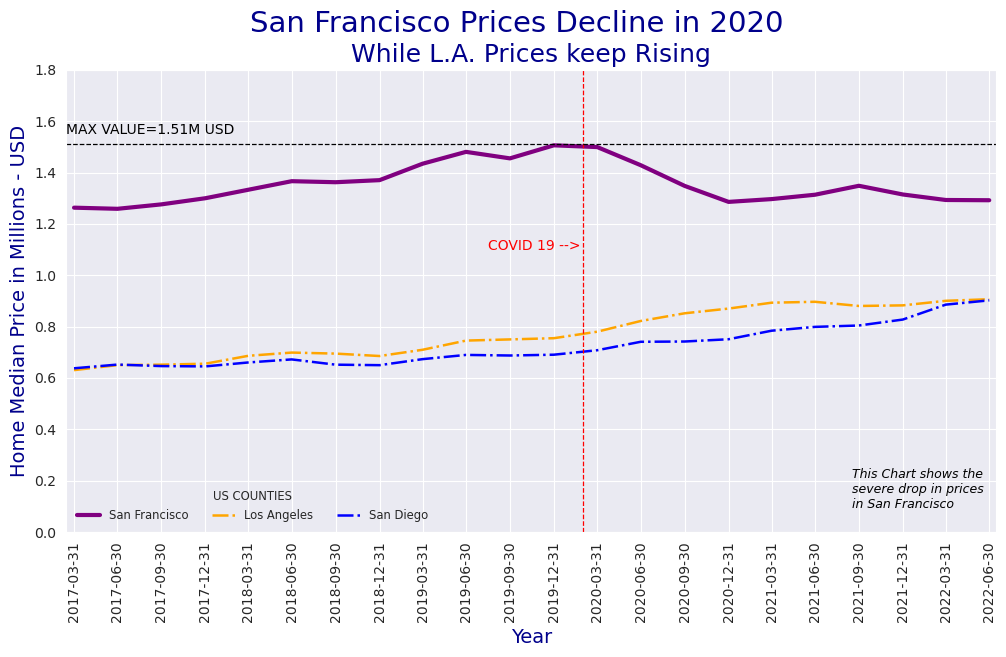

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df['San Francisco']/1e6, label='San Francisco', 
        linestyle='-', linewidth=3, color='purple')
ax.plot(df['Los Angeles']/1e6, label='Los Angeles', 
        linestyle='-.', linewidth=1.8, color='orange')
ax.plot(df['San Diego']/1e6, label='San Diego', 
        linestyle='-.', linewidth=1.8, color='blue')

fig.suptitle('San Francisco Prices Decline in 2020', fontsize=21, color='darkblue')
ax.set_title('While L.A. Prices keep Rising', fontsize=18, color='darkblue')
ax.set_xlabel('Year', fontsize=14, color='darkblue')
ax.set_ylabel('Home Median Price in Millions - USD', fontsize=14, color='darkblue')

ax.set_xlim(pd.Timestamp('2017-03-15'), pd.Timestamp('2022-07-15'))
ax.set_ylim(0, 1.8)

ax.set_xticks(df.index[:])
plt.xticks(rotation=90)

ax.axvline(x=pd.Timestamp('2020-03-01'), 
           color='red', ls='--', linewidth=0.9)
ax.text(x=pd.Timestamp('2019-08-15'), y=1.1, 
        s='COVID 19 -->', color='red')

ax.axhline(y=1.51, color='black', 
           ls='--', linewidth=0.9)
ax.text(x=pd.Timestamp('2017-03-15'), y=1.55, 
        s='MAX VALUE=1.51M USD', color='black')

fig.text(x=0.78, y=0.15, 
         s='This Chart shows the\nsevere drop in prices\nin San Francisco',
         fontstyle='italic', fontsize=9, color='black',)

ax.legend(loc='lower left',
          ncols=3, title='US COUNTIES',
          title_fontsize='small',
          fontsize='small', 
          frameon=False,
         )

plt.show()

<br><br>

>---
>**Annotations** are a great way to call-out and label important datapoints
>
>- `ax.annotate(string, datapoint coordinate, text_coordinate, arrow style dictionary,` textformatting`)`

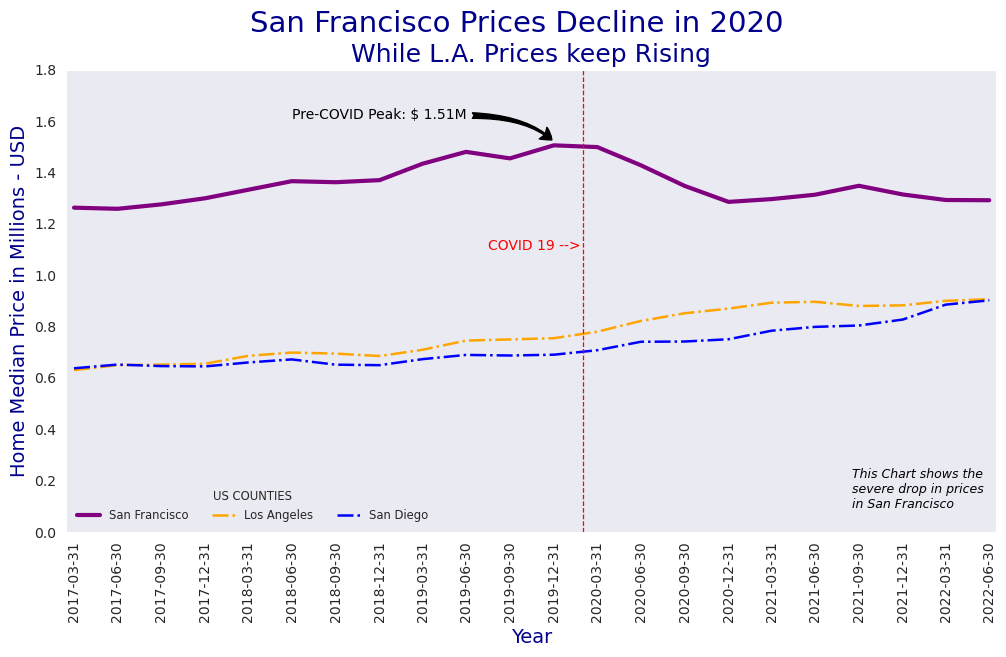

In [9]:
sns.set_style('dark')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df['San Francisco']/1e6, label='San Francisco', 
        linestyle='-', linewidth=3, color='purple')
ax.plot(df['Los Angeles']/1e6, label='Los Angeles', 
        linestyle='-.', linewidth=1.8, color='orange')
ax.plot(df['San Diego']/1e6, label='San Diego', 
        linestyle='-.', linewidth=1.8, color='blue')

fig.suptitle('San Francisco Prices Decline in 2020', fontsize=21, color='darkblue')
ax.set_title('While L.A. Prices keep Rising', fontsize=18, color='darkblue')
ax.set_xlabel('Year', fontsize=14, color='darkblue')
ax.set_ylabel('Home Median Price in Millions - USD', fontsize=14, color='darkblue')

ax.set_xlim(pd.Timestamp('2017-03-15'), pd.Timestamp('2022-07-15'))
ax.set_ylim(0, 1.8)

ax.set_xticks(df.index[:])
plt.xticks(rotation=90)

ax.axvline(x=pd.Timestamp('2020-03-01'), 
           color='red', ls='--', linewidth=0.9)

ax.text(x=pd.Timestamp('2019-08-15'), y=1.1, 
        s='COVID 19 -->', color='red')

# ----------------------------------------------------------
# ax.axhline(y=1.52, color='black', 
#            ls='--', linewidth=0.9)
# ax.text(x=pd.Timestamp('2017-03-15'), y=1.55, 
#         s='MAX VALUE=1.52M USD', color='black')
# ----------------------------------------------------------
# Second Alternative - Using Annotations:
ax.annotate('Pre-COVID Peak: $ 1.51M', 
            color='black',
            # "center", "top", "bottom", "baseline", "center_baseline"
            verticalalignment='top',
            # 'center', 'right', 'left'
            horizontalalignment='left',
            
            xy=(pd.Timestamp('2019-12-31'), 1.52),
            xytext=(pd.Timestamp('2018-06-30'), 1.65),
            
            arrowprops=dict(
                arrowstyle='fancy, head_width=1, head_length=0.8', #simple/fancy
                # relpos=(left=0, center=0.5, right=1), (low=0, center=0.5, top=1)
                relpos=(1, 0.5), 
                color='black',
                #Note: angleA=start point, angleB=end point
                connectionstyle='angle3, angleA=0, angleB=-45')
           )
# ----------------------------------------------------------
            
fig.text(x=0.78, y=0.15, 
         s='This Chart shows the\nsevere drop in prices\nin San Francisco',
         fontstyle='italic', fontsize=9, color='black',)

ax.legend(loc='lower left',
          ncols=3, title='US COUNTIES',
          title_fontsize='small',
          fontsize='small', 
          frameon=False,
         )

plt.show()